In [4]:
# Installing the Libraries
!pip install -q --upgrade \
    "langchain>=1.0,<2.0" \
    "langchain-core>=1.0,<2.0" \
    "langchain-community>=0.4.2" \
    "langchain-openai>=0.3.0" \
    "langchain-chroma>=0.2.0" \
    "langchain-text-splitters>=0.3.0" \
    "chromadb>=0.5.0" \
    "pypdf>=4.0.0" \
    "openai>=1.40.0" \
    "tiktoken>=0.7.0" \
    "dspy==3.2.1" \
    "scikit-learn>=1.4" \
    "yfinance>=0.2.40"
print("### Library Installation - Done")

### Library Installation - Done


installing Auth Codes

In [5]:
# Load the `config.json` file and extract API key + base URL
import json
import os

file_name = 'config.json'
with open(file_name, 'r') as file:
    config = json.load(file)
    # Corrected: Changed "API_KEY" to "API_Key" to match the key in config.json
    os.environ['OPENAI_API_KEY'] = config.get("API_Key")           # Loading the API Key
    os.environ["OPENAI_BASE_URL"] = config.get("OPENAI_API_BASE")  # Loading the API Base URL

print("API credentials loaded into the environment.")

API credentials loaded into the environment.


In [6]:
# Quick connectivity check — confirms the key + base URL actually reach a working endpoint
from openai import OpenAI

_client = OpenAI()
_ping = _client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[{"role": "user", "content": "Reply with exactly: OK"}],
    max_tokens=5,
)
print("Connectivity check:", _ping.choices[0].message.content)

Connectivity check: OK


Configuration & Shared Imports - Control panel

In [7]:
import warnings
warnings.filterwarnings('ignore')

import re
import time
import zipfile
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

pd.set_option("display.max_colwidth", 120)

In [8]:
# ---- Models ----------------------------------------------------------
# Single-model setup: gpt-4o-mini everywhere (see the cost note in Section 2).
MODEL_NAME      = "gpt-4o-mini"
EMBEDDING_MODEL = "text-embedding-3-small"

# ---- Companies under coverage ----------------------------------------
COMPANIES = ["GOOGL", "MSFT", "IBM", "NVDA", "AMZN"]

# ---- Retrieval & chunking knobs --------------------------------------
CHUNK_SIZE    = 512   # tokens per chunk (token-based splitting matches what models actually count)
CHUNK_OVERLAP = 64    # tokens shared between neighbouring chunks, so facts at boundaries aren't cut in half
TOP_K         = 4     # chunks retrieved per question

# ---- Evaluation & routing policy --------------------------------------
PASS_THRESHOLD       = 4      # a judge metric "passes" at >= 4 out of 5
CONF_CLIENT_READY    = 80     # confidence >= 80  -> ✅ client-ready
CONF_FLAGGED         = 60     # 60 <= conf < 80   -> ⚠️ flagged for awareness
                              # conf < 60         -> 🛑 held for human review
MAX_ANSWER_WORDS     = 30     # max words for concise answers

# ---- LLM objects -------------------------------------------------------
# Answerer — generates the RAG response. temperature=0 keeps answers stable
# and grounded; max_tokens caps response length.
llm = ChatOpenAI(model=MODEL_NAME, temperature=0, max_tokens=1024)

# Judge — a SEPARATE object so the evaluation role is explicit. In production
# this would be a stronger model; here it shares gpt-4o-mini for cost, which
# is exactly why Step 4 cross-validates the judges against the gold dataset.
judge_llm = ChatOpenAI(model=MODEL_NAME, temperature=0, max_tokens=600)

print(f"Configured: answerer={MODEL_NAME}, judge={MODEL_NAME}, embeddings={EMBEDDING_MODEL}")

Configured: answerer=gpt-4o-mini, judge=gpt-4o-mini, embeddings=text-embedding-3-small


3 year price chart

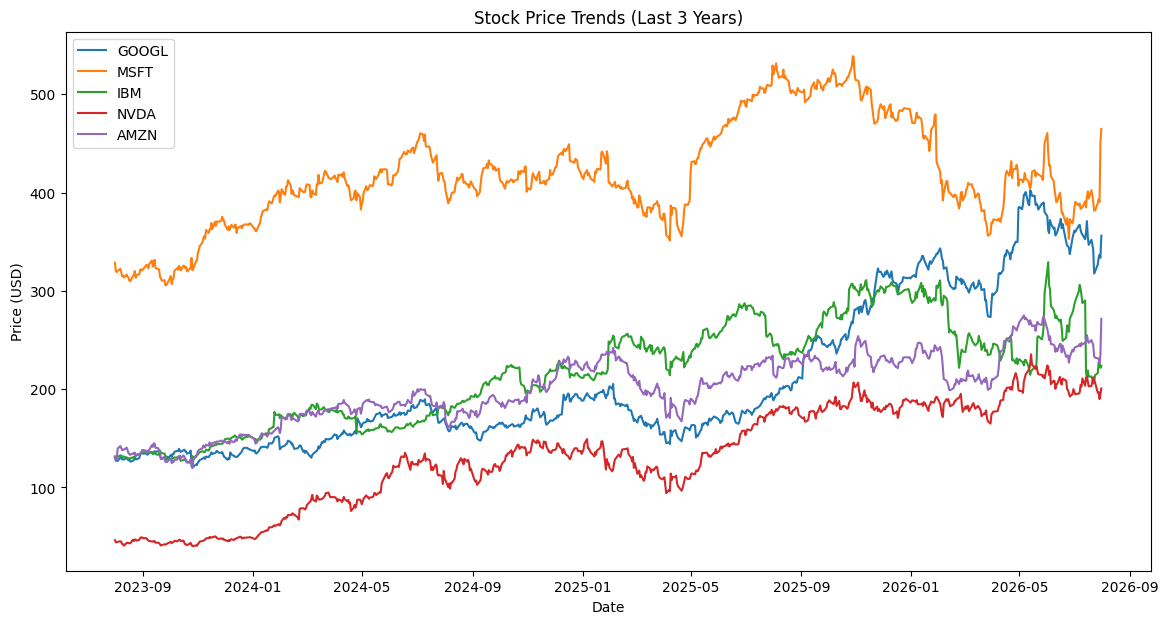

In [9]:
plt.figure(figsize=(14, 7))

for symbol in COMPANIES:
    ticker = yf.Ticker(symbol)
    data = ticker.history(period="3y")          # fetch this ticker's daily history for the last 3 years
    plt.plot(data.index, data['Close'], label=symbol)  # plot the 'Close' series, labelled with its symbol

plt.title("Stock Price Trends (Last 3 Years)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

Financial Metrics Data Frame

In [10]:
metrics_list = {}

for symbol in COMPANIES:
    ticker = yf.Ticker(symbol)
    info = ticker.info
    metrics_list[symbol] = {
        "Market Cap":     info.get("marketCap", 0),     # worked example
        "P/E Ratio":      info.get("trailingPE", 0),           # YOUR CODE
        "Dividend Yield": info.get("dividendYield", 0),        # YOUR CODE
        "Beta":           info.get("beta", 0),                 # YOUR CODE
        "Total Revenue":  info.get("totalRevenue", 0),         # YOUR CODE
    }

# Convert to a DataFrame (companies as the index) and make it readable:
fin_df = pd.DataFrame(metrics_list).T
fin_df["Market Cap"]    = fin_df["Market Cap"] / 1e9        # YOUR CODE: rescale to USD billions
fin_df["Total Revenue"] = fin_df["Total Revenue"] / 1e9     # YOUR CODE: rescale to USD billions
fin_df = fin_df.round(2)

fin_df



,Market Cap,P/E Ratio,Dividend Yield,Beta,Total Revenue
GOOGL,4355.45,17.86,0.25,1.25,445.87
MSFT,3450.80,25.90,0.78,1.13,331.84
IBM,210.71,19.88,3.02,0.68,69.09
NVDA,4862.37,30.79,0.50,2.21,253.49
AMZN,2921.42,21.83,0.00,1.46,775.68


Comparison charts

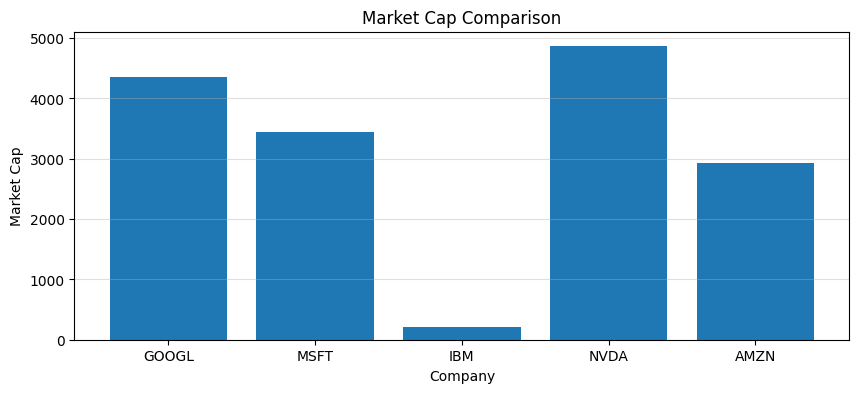

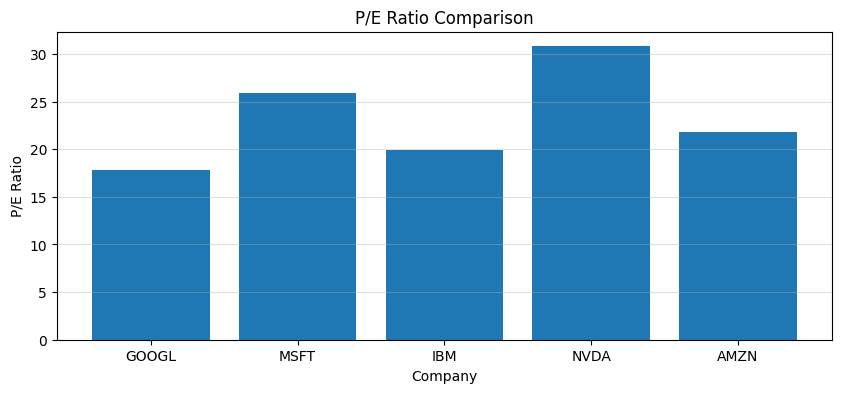

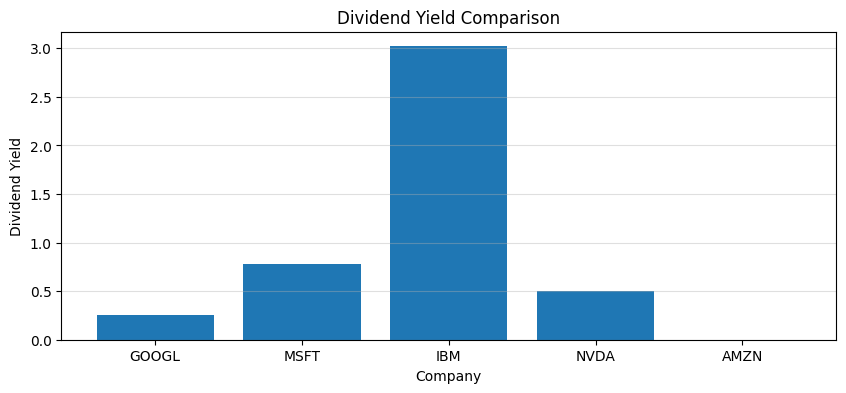

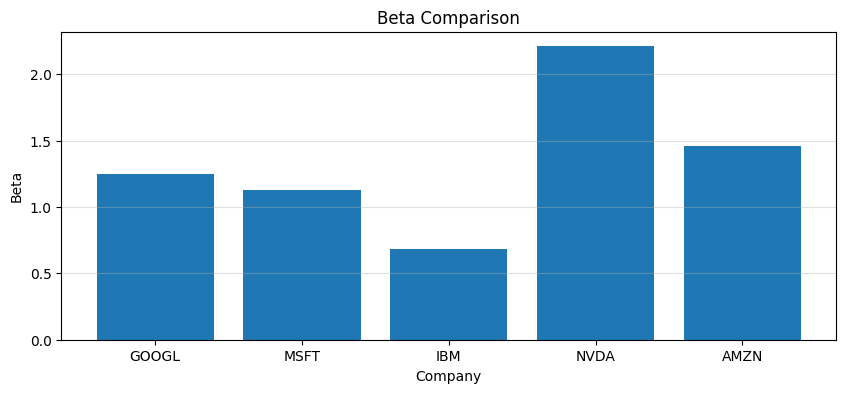

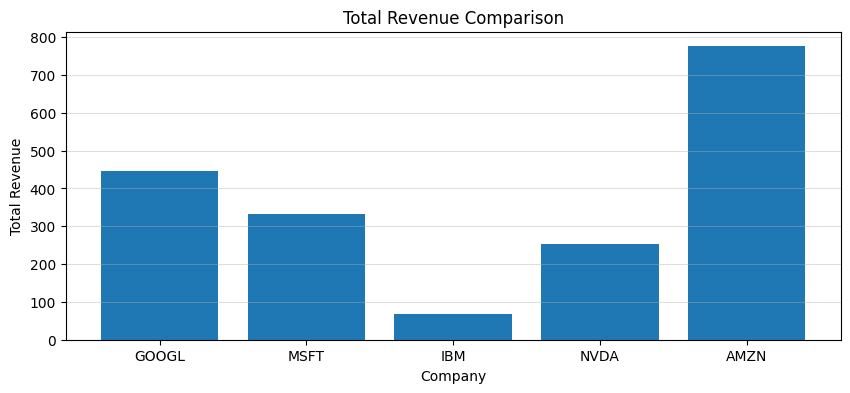

In [11]:
metrics_to_plot = ["Market Cap", "P/E Ratio", "Dividend Yield", "Beta", "Total Revenue"]

for metric in metrics_to_plot:
    plt.figure(figsize=(10, 4))
    plt.bar(fin_df.index, fin_df[metric])   # bar chart of fin_df[metric] across companies
    plt.title(f"{metric} Comparison")
    plt.ylabel(metric)
    plt.xlabel("Company")
    plt.grid(axis='y', alpha=0.4)
    plt.show()

**Observations - The financial Lens**

**NVDA reads as "priced for growth"**: highest P/E in the group paired with a near-zero dividend yield the market is paying a premium multiple on the expectation of future earnings growth rather than being compensated with cash payouts today.

**IBM reads as the defensive/dividend name:** by far the highest dividend yield 3%, roughly 4-6x the next closest company combined with the lowest market cap and a mid-pack P/E (~20) — a profile of a mature, income-generating business rather than a growth story, despite also having a much smaller market cap than the other four.

**What these numbers can't answer**: P/E and market cap tell you how the market is pricing each stock today, but not why — e.g., whether NVDA's premium is justified by a specific, defensible AI roadmap, or whether IBM's lower valuation reflects a weaker AI strategy versus just being a slower-growing legacy business. That's a qualitative judgment the numbers can't make, and it's exactly what the strategy PDFs (Narrative Lens, Stage 2) are for.

**Live-data caveat**: since this was pulled via yahoofinance at a specific moment, these exact multiples will drift — worth timestamping this snapshot in your writeup rather than treating it as a fixed fact.

Narritive Lens

In [12]:
ZIP_PATH    = "/content/Project_Datafiles (2).zip"
EXTRACT_DIR = "/content/"
PDF_DIR     = "/content/Companies-AI-Initiatives"

import zipfile
import os

if os.path.exists(ZIP_PATH):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)

    # Ensure PDF_DIR exists after extraction, then list files
    if os.path.exists(PDF_DIR):
        pdf_files = sorted(f for f in os.listdir(PDF_DIR) if f.endswith(".pdf"))
        print("Documents found:", pdf_files)
    else:
        print(f"Error: Extracted PDF directory not found at {PDF_DIR}.")
else:
    print(f"Error: Zip file not found at {ZIP_PATH}. Please ensure it is uploaded.")

Documents found: ['AMZN.pdf', 'GOOGL.pdf', 'IBM.pdf', 'MSFT.pdf', 'NVDA.pdf']


Load & Tag the metadata

In [13]:
# ═══════════════════════════════════════════════════════════════════════════
# This tag is what makes company-filtered retrieval possible in Step 3 — the
# fix for the pilot's company-mix-up failures. (It's also why we load each
# file individually instead of using PyPDFDirectoryLoader.)
# ───────────────────────────────────────────────────────────────────────────

documents = []

for fname in pdf_files:
    ticker = fname.replace(".pdf", "")     # "MSFT.pdf" -> "MSFT"
    loader = PyPDFLoader(os.path.join(PDF_DIR, fname))   # a PyPDFLoader for this file's full path
    pages  = loader.load()                               # load the file (one Document per page)
    for page in pages:
        page.metadata["company"] = ticker                # set this page's "company" metadata to the ticker
    documents.extend(pages)

print(f"Loaded {len(documents)} pages across {len(pdf_files)} companies.")

Loaded 44 pages across 5 companies.


Token Based Chunking

In [14]:
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name='cl100k_base',
    chunk_size=CHUNK_SIZE,        # use the constant from Section 3.3
    chunk_overlap=CHUNK_OVERLAP,  # use the constant from Section 3.3
)

chunks = text_splitter.split_documents(documents)   # split `documents` so metadata is preserved
print(f"Total chunks: {len(chunks)}")

Total chunks: 108


Chunk Sanity Check

In [15]:
chunk_counts = Counter(chunk.metadata["company"] for chunk in chunks)   # chunks per company
print("Chunks per company:", dict(chunk_counts))
print()
print("--- Sample chunk (first 400 chars) ---")
print(chunks[0].page_content[:400])   # first ~400 chars of one chunk
print(chunks[0].metadata)             # that chunk's metadata (confirm the company tag)

Chunks per company: {'AMZN': 25, 'GOOGL': 17, 'IBM': 22, 'MSFT': 19, 'NVDA': 25}

--- Sample chunk (first 400 chars) ---
Amazon  is  a  global  technology  and  e-commerce  giant  that  uses  AI  to  enhance  almost  every  part  
of
 
its
 
business.
 
In
 
retail,
 
AI
 
powers
 
product
 
recommendations,
 
dynamic
 
pricing,
 
fraud
 
detection,
 
and
 
supply
 
chain
 
optimization,
 
making
 
shopping
 
faster
 
and
 
more
 
personalized.
 
Amazon
 
Web
 
Services
 
(AWS)
 
offers
 
AI
 
and
 
machine
 
learni
{'producer': 'Skia/PDF m142 Google Docs Renderer', 'creator': 'PyPDF', 'creationdate': '', 'title': 'AI Initiatives', 'source': '/content/Companies-AI-Initiatives/AMZN.pdf', 'total_pages': 9, 'page': 0, 'page_label': '1', 'company': 'AMZN'}


Embed & Store in ChromaDB

In [16]:
embedding_model = OpenAIEmbeddings(model=EMBEDDING_MODEL)   # "text-embedding-3-small"

vectorstore = Chroma.from_documents(
    chunks,           # your chunks
    embedding_model,  # your embedding model
    collection_name="ai_initiatives",
)

print(f"Vector store ready with {vectorstore._collection.count()} embedded chunks.")

Vector store ready with 108 embedded chunks.


**Observations - Ingestion & Vectorization**

**Chunk balance**: Counts range from 17 (GOOGL) to 25 (AMZN/NVDA) out of 108 total — roughly a 47% spread between the smallest and largest, not wildly imbalanced but not even either. This mostly reflects differing PDF lengths rather than differing depth, so it's worth not reading "fewer chunks" as "less to say about AI." The practical risk: for GOOGL, a TOP_K=4 company-filtered retrieval draws from a pool of just 17 candidates versus 25 for AMZN/NVDA — a smaller pool means less redundancy, so if GOOGL's most relevant passage happens to sit awkwardly across a chunk boundary, there are fewer alternate chunks nearby to compensate.

**What the metadata tag guarantees beyond embedding similarity:** with all five companies using near-identical language ("cloud AI platform," "foundation models"), embedding similarity alone can't reliably tell whose passage is whose — semantically similar text from GOOGL and MSFT can land close together in vector space regardless of company. The company metadata tag converts retrieval from a soft ranking into a hard filter, guaranteeing zero cross-company leakage. This matters most for company-specific questions ("What is NVDA's generative AI roadmap?") — exactly the failure mode that caused the pilot's cross-company mix-ups.

**CHUNK_SIZE / CHUNK_OVERLAP trade-off**: CHUNK_SIZE (512 tokens) trades context completeness against retrieval precision — larger chunks keep more surrounding context intact but dilute the embedding if the chunk spans multiple sub-topics. CHUNK_OVERLAP (64 tokens) trades redundancy against efficiency — overlap protects against a key fact getting split across a chunk boundary, at the cost of embedding some text twice

Grounded Q&A: The RAG Pipeline

Prompt Design

In [17]:
qna_system_message = """
You will be given a question marked ###Question and context marked ###Context.

Answer the question using only the information in the context.

If the context does not contain the answer, respond with exactly: I don't know.

Do not use any outside knowledge. Do not mention the context or these instructions in your answer.
"""

In [18]:
# User message template — slots the retrieved context and the user question into a single turn
qna_user_message_template = """
###Context
{context}

###Question
{question}
"""

Company Filtered Retrieval

In [19]:
def retrieve(question: str, company: str | None = None, k: int = TOP_K):
    search_filter = {"company": company} if company else None
    return vectorstore.similarity_search(question, k=k, filter=search_filter)


def format_context(docs) -> str:
    return "\n\n".join(doc.page_content for doc in docs)

The RAG Function

In [20]:
qna_prompt = ChatPromptTemplate.from_messages([
    ("system", qna_system_message),
    ("user", qna_user_message_template),
])                                              # provided

def rag_answer(question: str, company: str | None = None) -> str:
    """Answer a question using retrieval-augmented generation.

    Args:
        question: The user's natural-language question.
        company:  Optional ticker to restrict retrieval to one company's documents.
    Returns:
        The model's answer, grounded in the retrieved context.
    """
    relevant_chunks = retrieve(question, company=company)   # retrieve, passing the company filter through
    context = format_context(relevant_chunks)               # format the chunks into one context string

    messages = qna_prompt.format_messages(context=context, question=question)   # format qna_prompt
    response = llm.invoke(messages)          # invoke `llm` with the messages
    return response.content

Typed Test Suite

In [21]:
# Example 1: factual lookup (single fact, single company)
print(rag_answer("What is Microsoft's flagship AI assistant product brand?", company="MSFT"))

Microsoft 365 Copilot


In [22]:
# Example 2: listing / multi-fact recall
print(rag_answer("What are the main AI initiatives NVIDIA is working on?", company="NVDA"))

The main AI initiatives NVIDIA is working on include Project G-Assist, which is an on-device AI assistant for GeForce RTX PCs, and Deep Learning Super Sampling (DLSS) 4, which is an AI-driven image upscaling and frame generation technology. Additionally, NVIDIA is focused on accelerating deep learning, generative AI, digital twins, and industrial automation across various industries.


In [23]:
# Example 3: cross-company comparison — no filter, the question itself names both companies
print(rag_answer("How does Google's AI focus differ from Microsoft's AI focus?", company=None))

Google's AI focus emphasizes enhancing user experience, automating workflows, enabling real-time decision-making, and driving innovation across industries, with a strong emphasis on responsible AI development and ethical deployment. In contrast, Microsoft's AI focus is on streamlining workflows, improving decision-making, and driving digital transformation, while also prioritizing responsible AI deployment, security, and compliance with ethical and regulatory standards.


In [24]:
# Example 4: multi-hop synthesis — links Amazon's customer-facing platform to its in-house foundation model
print(rag_answer("What is Amazon's foundation-model platform, and what foundation model has Amazon developed in-house?", company="AMZN"))

Amazon's foundation-model platform is called Amazon Bedrock. The foundation model that Amazon has developed in-house is named Olympus.


In [25]:
# Example 5: out-of-scope — tests the "I don't know" guardrail
print(rag_answer("What was IBM's exact revenue in the third quarter of 2025?", company="IBM"))

I don't know.


Retrieval diagnostics with a Gold Data Set

In [26]:
# 📂 Load the gold dataset
gold = pd.read_csv("/content/golden_retrieval.csv")
print(f"{len(gold)} gold questions, balanced across companies:")
print(gold["ticker_hint"].value_counts().to_dict())
gold.head()

20 gold questions, balanced across companies:
{'MSFT': 4, 'GOOGL': 4, 'IBM': 4, 'NVDA': 4, 'AMZN': 4}


,question,ticker_hint,expected_substring
0,What is Microsoft's flagship AI assistant product brand?,MSFT,Copilot
1,Which Microsoft cloud platform hosts AI services?,MSFT,Azure
2,What is Microsoft's AI development platform for foundation models?,MSFT,Foundry
3,Which Microsoft tool delivers AI-assisted code completion?,MSFT,IntelliCode
4,What is Google's primary foundation-model family?,GOOGL,Gemini


In [27]:
def retrieval_diagnostic(row, use_filter: bool) -> dict:
    """For one gold row: did the expected token reach the retrieved chunks,
    and (for unfiltered retrieval) what share of chunks belong to the right company?"""
    company = row["ticker_hint"] if use_filter else None          # the row's ticker_hint when use_filter, else None
    docs    = retrieve(row["question"], company=company)          # retrieve this row's question with that company setting
    text    = " ".join(doc.page_content for doc in docs).lower()  # join retrieved chunks' text, lowercased

    return {
        "hit":    row["expected_substring"].lower() in text,      # is expected_substring (lowercased) in the text?
        "purity": sum(doc.metadata["company"] == row["ticker_hint"] for doc in docs) / len(docs),  # fraction right-company
    }

In [28]:
# Run diagnostics for filtered retrieval
filtered_diagnostics = gold.apply(lambda row: retrieval_diagnostic(row, use_filter=True), axis=1, result_type='expand')

# Run diagnostics for unfiltered retrieval
unfiltered_diagnostics = gold.apply(lambda row: retrieval_diagnostic(row, use_filter=False), axis=1, result_type='expand')

print("--- Filtered Retrieval Metrics ---")
print(f"Average Hit Rate: {filtered_diagnostics['hit'].mean():.2f}")
print(f"Average Purity: {filtered_diagnostics['purity'].mean():.2f}")

print("\n--- Unfiltered Retrieval Metrics ---")
print(f"Average Hit Rate: {unfiltered_diagnostics['hit'].mean():.2f}")
print(f"Average Purity: {unfiltered_diagnostics['purity'].mean():.2f}")

--- Filtered Retrieval Metrics ---
Average Hit Rate: 0.85
Average Purity: 1.00

--- Unfiltered Retrieval Metrics ---
Average Hit Rate: 0.85
Average Purity: 0.99


In [29]:
# Example 5: out-of-scope — tests the "I don't know" guardrail
print(rag_answer("What was IBM's exact revenue in the third quarter of 2025?", company="IBM"))

I don't know.


**Observations - RAG Pipeline & Retrieval Diagnostics**

The guardrail in Example 5 behaved as expected, responding with "I don't know" because the information was out of scope. This is a critical safety feature. Hexplaining why an honest miss is safer than a confident fabrication

**Did the filter change the result on THIS gold set — and if not, why not?**

Consider the phrasing of the questions in the `gold` dataset. Many of them explicitly mention the company name (e.g., "What is **Microsoft's** flagship AI assistant product brand?"). This strong signal in the query itself often guides the semantic search effectively even without an explicit filter. Therefore, if the questions are already very specific to a company, the impact on the *hit rate* might be minimal, as the semantic search could retrieve relevant company-specific chunks anyway.



**The filter still earns its keep** and is crucial, in scenarios where:

**Ambiguous or Generic Queries:** When the user asks a question that could apply to multiple companies or uses generic terms (e.g., "What are the main AI initiatives?"). Without the filter, the retriever might return chunks from various companies, leading to mixed or incorrect answers, especially if the semantic similarity across companies is high.
**Explicit Company Focus:** When the user explicitly wants information *only* from a particular company, regardless of the query's phrasing. The filter provides a hard constraint, guaranteeing that no information from other companies 'leaks' into the retrieved context.
**Preventing Hallucinations/Mix-ups:** As mentioned in previous observations, if multiple companies use similar terminology for their products or strategies, the filter prevents the model from mixing up information between companies. For example, if both Google and Microsoft have 'cloud AI platforms' with similar descriptions, an unfiltered retrieval might return a mix, leading to a fabricated answer about one company based on another's context.
**Scaling and Robustness:** For a larger dataset with more companies and more nuanced similarities, the filter becomes indispensable for maintaining accuracy and control over the source of information.

Quality Control: LLM-as-Judge Evaluation

In [30]:
# Five evaluation questions with their retrieval scope. Q4 is intentionally
# unanswerable from the source so we can observe the rubric correctly
# penalising context-relevance and answer-relevance.
evaluation_set = [
    {"question": "What is Google's primary foundation-model family?",                          "company": "GOOGL"},
    {"question": "What are the main AI initiatives IBM is pursuing?",                          "company": "IBM"},
    {"question": "How does NVIDIA's AI strategy differ from Amazon's AI strategy?",            "company": None},
    {"question": "What was Microsoft's total AI revenue for fiscal year 2025?",                "company": "MSFT"},   # out-of-scope trap
    {"question": "What timelines are mentioned for Amazon's foundation-model initiatives?",    "company": "AMZN"},
]

Judge Rubric 1 - Groundedness

In [31]:
# User-side template for the groundedness judge — supplies question, context and answer
groundedness_evaluation_message_template = """
###Question
{question}

###Context
{context}

###Answer
{answer}
"""

# System prompt for the groundedness judge — scores how well the answer is
# derived from the provided context, on a 1-5 scale.
# The final "Score: N" line makes the rating machine-readable for the batch evaluator.
groundedness_rater_system_message = """You are tasked with rating AI-generated answers to questions posed by users.
You will be presented a question, the context used by the AI system, and the AI-generated answer.
In the input, the question begins with ###Question, the context begins with ###Context, and the answer begins with ###Answer.

Metric:
Groundedness — the answer should be derived ONLY from the information presented in the context. Claims that do not appear in the context lower the score.

Evaluation criteria (1-5):
1 - The metric is not followed at all
2 - The metric is followed only to a limited extent
3 - The metric is followed to a good extent
4 - The metric is followed mostly
5 - The metric is followed completely

Instructions:
1. Briefly explain, step by step, whether each claim in the answer is supported by the context.
2. Then assign a rating using the evaluation criteria.
3. End your response with a line in EXACTLY this format: Score: <N>
"""

Judge Rubric 2 - Context Relevance

In [32]:
context_relevance_evaluation_message_template = """
###Question
{question}

###Context
{context}
"""

context_relevance_rater_system_message = """You are tasked with rating the quality of retrieved context for a question-answering system.
You will be presented a question and the context retrieved by the system.
In the input, the question begins with ###Question and the context begins with ###Context.

Metric:
Context Relevance — the retrieved context should contain the information needed to answer the question. The score should reflect how much of the context is directly useful for answering the question, versus irrelevant or off-topic material. A score should be lowered if the context is missing the information the question asks for, if it contains information about the wrong company or topic, or if it is dominated by passages unrelated to the question even when some relevant material is present.

Evaluation criteria (1-5):
1 - The metric is not followed at all
2 - The metric is followed only to a limited extent
3 - The metric is followed to a good extent
4 - The metric is followed mostly
5 - The metric is followed completely

Instructions:
1. Briefly explain, step by step, whether the context contains the information needed to answer the question, and note any irrelevant or off-topic material present.
2. Then assign a rating using the evaluation criteria.
3. End your response with a line in EXACTLY this format: Score: <N>
"""



Judge Rubric 3 - Context Relevance

In [33]:
answer_relevance_evaluation_message_template = """
###Question
{question}

###Answer
{answer}
"""

answer_relevance_rater_system_message = """You are tasked with rating AI-generated answers to questions posed by users.
You will be presented a question and the AI-generated answer.
In the input, the question begins with ###Question and the answer begins with ###Answer.

Metric:
Answer Relevance — the answer should directly address the main aspects of the question asked, without omitting key parts of what was asked or drifting into unrelated information. A score should be lowered if the answer is incomplete relative to the question, addresses only a portion of a multi-part question, or fails to engage with what was actually asked — even if the answer's content is otherwise accurate.

Evaluation criteria (1-5):
1 - The metric is not followed at all
2 - The metric is followed only to a limited extent
3 - The metric is followed to a good extent
4 - The metric is followed mostly
5 - The metric is followed completely

Instructions:
1. Briefly explain, step by step, whether the answer addresses the main aspects of the question.
2. Then assign a rating using the evaluation criteria.
3. End your response with a line in EXACTLY this format: Score: <N>
"""


The Evaluation

In [34]:
def extract_score(judge_text: str) -> int:
    """Pull the final 1-5 integer score from a judge response.
    Falls back to the last 1-5 mentioned anywhere if the 'Score: N' line is
    missing (defensive); returns 0 if no digit is found."""
    m = re.findall(r"(?im)^Score:\s*([1-5])", judge_text)   # find all "Score: <N>" line matches (N in 1-5)
    if m:
        return int(m[-1])
    nums = re.findall(r"\b([1-5])\b", judge_text)            # fallback — all standalone digits 1-5 anywhere in the text
    return int(nums[-1]) if nums else 0

In [35]:
# Compile each rubric as a reusable ChatPromptTemplate so we can format
# per-question inputs in the evaluation loop below.
groundedness_prompt = ChatPromptTemplate.from_messages([
    ("system", groundedness_rater_system_message),
    ("user", groundedness_evaluation_message_template),
])

context_relevance_prompt = ChatPromptTemplate.from_messages([
    ("system", context_relevance_rater_system_message),
    ("user", context_relevance_evaluation_message_template),
])

answer_relevance_prompt = ChatPromptTemplate.from_messages([
    ("system", answer_relevance_rater_system_message),
    ("user", answer_relevance_evaluation_message_template),
])

In [36]:
def evaluate_question(question: str, company: str | None) -> dict:
    docs    = retrieve(question, company=company)          # retrieve with the company filter
    context = format_context(docs)                         # format the context
    answer  = rag_answer(question, company=company)        # generate the answer with rag_answer()

    g = judge_llm.invoke(
        groundedness_prompt.format_messages(question=question, context=context, answer=answer)
    ).content
    c = judge_llm.invoke(
        context_relevance_prompt.format_messages(question=question, context=context)
    ).content
    a = judge_llm.invoke(
        answer_relevance_prompt.format_messages(question=question, answer=answer)
    ).content

    return {
        "question": question,
        "answer": answer,
        "groundedness":      extract_score(g),
        "context_relevance": extract_score(c),
        "answer_relevance":  extract_score(a),
    }

# Provided: run every question through the pipeline.
# 5 questions x (1 RAG + 3 judges) = 20 LLM calls — expect ~30-60 seconds.
judge_results = [evaluate_question(item["question"], item["company"]) for item in evaluation_set]
print("Evaluation complete.")

Evaluation complete.


In [37]:
judge_df = pd.DataFrame(judge_results)                              # provided
judge_df.insert(0, "Q#", [f"Q{i+1}" for i in range(len(judge_results))])   # provided

judge_df["pass_all"] = (
    (judge_df["groundedness"] >= PASS_THRESHOLD) &
    (judge_df["context_relevance"] >= PASS_THRESHOLD) &
    (judge_df["answer_relevance"] >= PASS_THRESHOLD)
)   # True only when ALL THREE metrics are >= PASS_THRESHOLD

# Show scores only — full questions/answers are inspected in the next cell
judge_df[["Q#", "groundedness", "context_relevance", "answer_relevance", "pass_all"]]

,Q#,groundedness,context_relevance,answer_relevance,pass_all
0,Q1,5,4,5,True
1,Q2,5,4,5,True
2,Q3,1,3,1,False
3,Q4,5,2,1,False
4,Q5,5,3,5,False


Gold Set Accuracy

In [38]:
def run_gold_set(answer_fn) -> pd.DataFrame:
    """Run every gold question through `answer_fn(question, ticker)` and score hits."""
    rows = []
    for _, row in gold.iterrows():
        ans = answer_fn(row["question"], row["ticker_hint"])   # call answer_fn with this row's question and ticker_hint
        rows.append({
            "ticker":    row["ticker_hint"],
            "question":  row["question"],
            "expected":  row["expected_substring"],
            "answer":    ans,
            "exact_hit": row["expected_substring"].lower() in ans.lower(),   # case-insensitive substring check
        })
    return pd.DataFrame(rows)

baseline_gold_df = run_gold_set(lambda question, ticker: rag_answer(question, company=ticker))

# Provided: the baseline numbers
baseline_accuracy = baseline_gold_df["exact_hit"].mean()
print(f"v1.0 BASELINE gold-set accuracy: {baseline_gold_df['exact_hit'].sum()}/{len(baseline_gold_df)}  ({baseline_accuracy:.0%})")
print()
print("Per-company hit-rate:")
print(baseline_gold_df.groupby("ticker")["exact_hit"].mean().round(2))

v1.0 BASELINE gold-set accuracy: 12/20  (60%)

Per-company hit-rate:
ticker
AMZN     1.00
GOOGL    0.75
IBM      0.25
MSFT     0.50
NVDA     0.50
Name: exact_hit, dtype: float64


In [39]:
# 🔍 Inspect the objective misses — what did the v1.0 prompt get wrong?
# These exact failures become the feedback GEPA will learn from in Step 5.
misses = baseline_gold_df[~baseline_gold_df["exact_hit"]]
if misses.empty:
    print("No misses — the baseline already answers every gold question. "
          "(GEPA will then optimize for precision/conciseness rather than recall.)")
else:
    for _, m in misses.iterrows():
        print(f"=== {m['ticker']} | expected token: '{m['expected']}' ===")
        print(f"Q: {m['question']}")
        print(f"A: {m['answer']}")
        print()

=== MSFT | expected token: 'Foundry' ===
Q: What is Microsoft's AI development platform for foundation models?
A: I don't know.

=== MSFT | expected token: 'IntelliCode' ===
Q: Which Microsoft tool delivers AI-assisted code completion?
A: GitHub Copilot delivers AI-assisted code completion.

=== GOOGL | expected token: 'TPU' ===
Q: Which accelerator chip does Google use to train its large models?
A: I don't know.

=== IBM | expected token: 'watsonx' ===
Q: What is IBM's enterprise AI platform branded as?
A: IBM's enterprise AI platform is branded as Watson.

=== IBM | expected token: 'Guardium' ===
Q: What is IBM's data security and governance product family?
A: I don't know.

=== IBM | expected token: 'Quantum' ===
Q: What advanced computing area does IBM emphasise alongside AI?
A: I don't know.

=== NVDA | expected token: 'NIM' ===
Q: Which NVIDIA microservice framework deploys foundation models?
A: I don't know.

=== NVDA | expected token: 'Flamingo' ===
Q: What is the NVIDIA in-gam

**Observations - What the Two Evaluations Tell Us**

**Why Q4's failure is a success, and which metric passes**

Q4 (groundedness=5, context_relevance=2, answer_relevance=1, pass_all=False) fails exactly as designed: it fails context-relevance (the retrieved chunks don't contain Microsoft revenue data — there's nothing relevant to find) and answer-relevance (the answer doesn't give the user the number they asked for). But groundedness passes at 5/5 — a refusal like "I don't know." makes zero claims that aren't supported by the context, so it's trivially, perfectly grounded.

This tells you what each metric actually isolates: groundedness measures faithfulness to what was retrieved, independent of whether that retrieval was useful. Context/answer relevance measure usefulness to the actual question. An answer can max out faithfulness while being completely unhelpful — that's precisely the guardrail's honest-miss behavior, and it's why a single blended score would have hidden this distinction entirely.

**Classifying the 8 gold-set misses**

IBM is the clear outlier: 0.25 hit-rate (only 1/4 correct) — watsonx, Guardium, and Quantum all missed. Three misses concentrated in one company, out of only 4 questions, is a strong signal something is systematically wrong with IBM's retrieval or chunking specifically — not a generic prompt weakness (a prompt problem would hit all companies roughly evenly, not IBM at 3x the miss rate of GOOGL).

The 5 "I don't know" cases (Foundry, TPU, Guardium, Quantum, NIM) are honest refusals rather than fabrications — that's the guardrail working, but it still leaves the question unanswered. Without diag_df, I can't say definitively whether the term never reached the top-K chunks (retrieval failure) or reached it but the generator was over-cautious (generation failure) — that's the check worth running before Step 5.

The 3 confident-wrong cases (IntelliCode→Copilot, watsonx→Watson, Flamingo→Project G-Assist) are more diagnostic even without diag_df: each substituted a real, plausible adjacent product name rather than fabricating something ungrounded. That pattern — fluent, wrong, but topically adjacent — is the signature of retrieval surfacing the wrong chunk (one about a related-but-different product), not the generator inventing facts from nothing.

Dominant pattern in the run: honest refusal (5/8) outweighs confident wrong answers (3/8) — a genuinely good sign, since it means the guardrail is doing its job more often than it's failing. But given IBM's disproportionate miss count, the dominant underlying cause looks more like a retrieval/coverage gap concentrated in specific companies' chunk sets than a generic prompt weakness — which matters because GEPA (Step 5) can only rewrite the prompt, not fix retrieval. Running retrieval_diagnostic() on the 8 missed tokens with use_filter=True before Step 5 would confirm this and tell you which misses are even fixable by prompt optimization.

**A judge/substring disagreement**

The IntelliCode case is a clean real example: the answer "GitHub Copilot delivers AI-assisted code completion" is a coherent, plausibly well-grounded claim (Copilot is a real, documented product) — a groundedness judge would likely score it high, since nothing in that sentence is unsupported by some retrieved content. Yet exact_hit=False, because the gold answer required "IntelliCode" specifically, and the system answered a different, adjacent question.

Both can be "right" simultaneously because they're measuring different things: groundedness asks "is this claim supported by what was retrieved," while the substring check asks "did the system answer the specific fact the gold set requires." A judge has no way to know the gold key exists — it can only assess the answer on its own terms, so a well-grounded answer to the wrong specific fact still scores well.

This is exactly why GEPA gets handed the objective (substring) signal rather than judge scores: an optimizer chasing judge scores could learn to produce fluent, well-grounded, confidently-substituted answers — improving groundedness while never actually getting closer to the correct fact. The substring check has no such blind spot; it only rewards the literal correct token appearing, giving GEPA a harder, unhackable target.

**The number Step 5 must beat**

12/20 = 60%

Prompt Training

In [40]:
# ── DSPy LM configuration ─────────────────────────────────────────────────────
# DSPy routes every LLM call through LiteLLM, so we point it at the same
# API key / base URL used by the rest of the notebook.
#
# Two LMs are configured because GEPA runs a two-model loop:
#   - task_lm        : runs the candidate RAG prompt during compilation and at
#                      inference time. Low temperature for deterministic outputs.
#   - reflection_lm  : reads the metric's natural-language feedback and proposes
#                      the next prompt mutation. Higher temperature gives the
#                      reflection step useful variation. (Production tip: a
#                      stronger model here usually finds better rewrites; we
#                      stay on gpt-4o-mini for cost — our crisp deterministic
#                      feedback is what keeps a small reflector effective.)
import dspy

task_lm = dspy.LM(
    model       = "openai/gpt-4o-mini",
    api_key     = os.environ['OPENAI_API_KEY'],
    api_base    = os.environ["OPENAI_BASE_URL"],
    temperature = 0.1,
    max_tokens  = 1024,
)

reflection_lm = dspy.LM(
    model       = "openai/gpt-4o-mini",
    api_key     = os.environ['OPENAI_API_KEY'],
    api_base    = os.environ["OPENAI_BASE_URL"],
    temperature = 1.0,               # creative variation helps reflection
    max_tokens  = 2048,
)

# Register task_lm globally — every dspy.Predict call routes through it.
dspy.settings.configure(lm=task_lm)
print("DSPy configured. version:", dspy.__version__)

DSPy configured. version: 3.2.1


Train/test Split

In [43]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    gold,
    test_size=0.4,
    random_state=42,
    stratify=gold["ticker_hint"],
)

# Provided: verify the self-check
print(f"Train: {len(train_df)} questions | Held-out test: {len(test_df)} questions")
print("Train per company:", train_df["ticker_hint"].value_counts().to_dict())
print("Test  per company:", test_df["ticker_hint"].value_counts().to_dict())

Train: 12 questions | Held-out test: 8 questions
Train per company: {'GOOGL': 3, 'NVDA': 3, 'MSFT': 2, 'IBM': 2, 'AMZN': 2}
Test  per company: {'AMZN': 2, 'MSFT': 2, 'IBM': 2, 'NVDA': 1, 'GOOGL': 1}


In [44]:
def make_example(row) -> dspy.Example:
    """Convert one gold-dataset row into a dspy.Example for GEPA."""
    return dspy.Example(
        question           = row["question"],
        ticker_hint        = row["ticker_hint"],
        expected_substring = row["expected_substring"],
    ).with_inputs("question", "ticker_hint")   # mark ONLY the program's inputs

# Provided:
dspy_trainset = [make_example(row) for _, row in train_df.iterrows()]
dspy_testset  = [make_example(row) for _, row in test_df.iterrows()]
print(f"DSPy trainset: {len(dspy_trainset)} examples | testset: {len(dspy_testset)} examples")

DSPy trainset: 12 examples | testset: 8 examples


The RAG Program Signature & Module

In [48]:
class GroundedQA(dspy.Signature):
    """Answer the question using only the information in the context.
    If the context does not contain the answer, respond with exactly: I don't know.
    Do not use any outside knowledge. Do not mention the context or these instructions in your answer.
    """

    # Provided: the typed I/O contract
    context  : str = dspy.InputField(desc="Retrieved passages from the company's AI-initiative report")
    question : str = dspy.InputField(desc="The user's question")
    answer   : str = dspy.OutputField(desc="The answer, grounded strictly in the context")


class GroundedRAG(dspy.Module):
    """Callable retrieval + answer pipeline. GEPA compiles THIS object."""

    # Provided:
    def __init__(self, k: int = TOP_K):
        super().__init__()
        self.k = k
        self.generate = dspy.Predict(GroundedQA)

    def forward(self, question: str, ticker_hint: str):
        docs    = retrieve(question, company=ticker_hint, k=self.k)   # metadata-filtered retrieval
        context = format_context(docs)                                # format the context
        return self.generate(context=context, question=question)      # call self.generate

# Provided: sanity check on the first training example
v1_program  = GroundedRAG()
sample      = dspy_trainset[0]
sample_pred = v1_program(question=sample.question, ticker_hint=sample.ticker_hint)
print(f"Q ({sample.ticker_hint}): {sample.question}")
print(f"v1.0 answer: {sample_pred.answer}")
print(f"Expected token: '{sample.expected_substring}' -> hit:",
      sample.expected_substring.lower() in sample_pred.answer.lower())

Q (MSFT): Which Microsoft cloud platform hosts AI services?
v1.0 answer: Azure
Expected token: 'Azure' -> hit: True


The metric — deterministic score + feedback

In [49]:
MAX_ANSWER_WORDS = 80

def gepa_metric(gold_ex, pred, trace=None, pred_name=None, pred_trace=None):
    """Score + natural-language feedback for GEPA, from the gold dataset."""
    answer   = (pred.answer or "").strip()
    expected = gold_ex.expected_substring
    n_words  = len(answer.split())
    hit      = expected.lower() in answer.lower()

    if hit and n_words <= MAX_ANSWER_WORDS:                       # worked example
        score    = 1.0
        feedback = (f"Correct: the answer names '{expected}' and stays concise "
                    f"({n_words} words). Keep answering with the specific product/initiative name.")
    elif hit:
        score    = 0.7
        feedback = (f"The answer correctly names '{expected}', but at {n_words} words it is "
                    f"too long (limit {MAX_ANSWER_WORDS}). Answer in 1-3 precise sentences — "
                    f"state the specific product/initiative name directly without padding, "
                    f"repetition, or restating the question.")
    elif "i don't know" in answer.lower():
        score    = 0.0
        feedback = (f"Incorrect refusal: the context DID contain the answer '{expected}', "
                    f"but the model said 'I don't know.' Do not refuse when the retrieved "
                    f"context actually contains the specific fact asked for — only refuse "
                    f"when the context is truly silent on the question.")
    else:
        score    = 0.0
        feedback = (f"Missed: the answer did not mention '{expected}', which is the specific "
                    f"product/initiative name the question requires. Do not substitute an "
                    f"adjacent or more familiar-sounding product name — quote the exact "
                    f"term as it appears in the context.")

    return dspy.Prediction(score=score, feedback=feedback)

# Provided: smoke-test on the sanity-check prediction from the previous cell
print(gepa_metric(sample, sample_pred))


Prediction(
    score=1.0,
    feedback="Correct: the answer names 'Azure' and stays concise (1 words). Keep answering with the specific product/initiative name."
)


GEPA Compliation

In [50]:
# The evolutionary loop: run candidates on the trainset, read the metric's
# feedback, rewrite the GroundedQA docstring, keep the winners.
from dspy.teleprompt import GEPA

start_time = time.time()

gepa = GEPA(
    metric        = gepa_metric,
    auto          = "light",          # efficient preset; raise to "medium" for a deeper search
    reflection_lm = reflection_lm,
    track_stats   = True,
    seed          = 42,
)

optimised_program = gepa.compile(
    student  = GroundedRAG(),
    trainset = dspy_trainset,
)

optimised_program.save("gepa_optimised_rag.json")
elapsed = time.time() - start_time
print("GEPA compilation complete.")
print("=" * 50)
print(f"Time taken for optimization by GEPA : {elapsed:.1f} seconds")
print("=" * 50)

2026/08/02 08:22:42 INFO dspy.teleprompt.gepa.gepa: Running GEPA for approx 428 metric calls of the program. This amounts to 35.67 full evals on the train set.
2026/08/02 08:22:42 WARNING dspy.teleprompt.gepa.gepa: No valset provided; Using trainset as valset. This is useful as an inference-time scaling strategy where you want GEPA to find the best solutions for the provided tasks in the trainset, as it makes GEPA overfit prompts to the provided trainset. In order to ensure generalization and perform well on unseen tasks, please provide separate trainset and valset. Provide the smallest valset that is just large enough to match the downstream task distribution, while keeping trainset as large as possible.
2026/08/02 08:22:42 INFO dspy.teleprompt.gepa.gepa: Using 12 examples for tracking Pareto scores.
GEPA Optimization:   0%|          | 0/428 [00:00<?, ?rollouts/s]2026/08/02 08:22:47 INFO dspy.evaluate.evaluate: Average Metric: 9.0 / 12 (75.0%)
2026/08/02 08:22:47 INFO dspy.teleprompt.

Average Metric: 3.00 / 3 (100.0%): 100%|██████████| 3/3 [00:00<00:00,  3.38it/s]

2026/08/02 08:22:48 INFO dspy.evaluate.evaluate: Average Metric: 3.0 / 3 (100.0%)
2026/08/02 08:22:48 INFO dspy.teleprompt.gepa.gepa: Iteration 1: All subsample scores perfect. Skipping.
2026/08/02 08:22:48 INFO dspy.teleprompt.gepa.gepa: Iteration 1: Reflective mutation did not propose a new candidate
GEPA Optimization:   4%|▎         | 15/428 [00:05<02:25,  2.85rollouts/s]2026/08/02 08:22:48 INFO dspy.teleprompt.gepa.gepa: Iteration 2: Selected program 0 score: 0.75



Average Metric: 2.00 / 3 (66.7%): 100%|██████████| 3/3 [00:01<00:00,  2.86it/s]

2026/08/02 08:22:49 INFO dspy.evaluate.evaluate: Average Metric: 2.0 / 3 (66.7%)


...

2026/08/02 08:26:00 INFO dspy.evaluate.evaluate: Average Metric: 2.0 / 3 (66.7%)


2026/08/02 08:26:03 INFO dspy.teleprompt.gepa.gepa: Iteration 106: Proposed new text for generate: Answer the question using only the information provided in the context. If the context does not contain the answer, respond with "I don't know." 

1. Extract the most specific and accurate term or name related to the question, ensuring to quote it exactly as it appears in the context. 
2. Provide concise answers that directly address the questions—preferably using single words or very short phrases when possible.
3. Do not generalize or substitute product names or initiatives; always use the exact term from the context.
4. Avoid including any outside knowledge or information; focus solely on the details presented within the context provided.
5. If multiple relevant details are present in the context, choose the most pertinent one that best answers the question. 
6. Pay careful attention to the distinction between general terms and specific initiatives or products mentioned in the context 

Average Metric: 3.00 / 3 (100.0%): 100%|██████████| 3/3 [00:00<00:00,  5.23it/s]

2026/08/02 08:26:06 INFO dspy.evaluate.evaluate: Average Metric: 3.0 / 3 (100.0%)
2026/08/02 08:26:06 INFO dspy.teleprompt.gepa.gepa: Iteration 107: All subsample scores perfect. Skipping.
2026/08/02 08:26:06 INFO dspy.teleprompt.gepa.gepa: Iteration 107: Reflective mutation did not propose a new candidate
GEPA Optimization: 100%|█████████▉| 426/428 [03:23<00:00,  2.10rollouts/s]


GEPA compilation complete.
Time taken for optimization by GEPA : 203.1 seconds


Inspect the Evolved Prompt

In [63]:
# ── Display the GEPA-evolved prompt ───────────────────────────────────────────
print("=" * 78)
print("v1.0 PROMPT (what we started with):")
print("=" * 78)
print(GroundedQA.__doc__)

for name, predictor in optimised_program.named_predictors():
    print()
    print("=" * 78)
    print(f"v2.0 PROMPT — GEPA-evolved instructions for predictor '{name}':")
    print("=" * 78)
    print(predictor.signature.instructions)
    demos = getattr(predictor, "demos", [])
    print()
    print(f"Few-shot demos attached by GEPA: {len(demos)}")

v1.0 PROMPT (what we started with):
Answer the question using only the information in the context.
    If the context does not contain the answer, respond with exactly: I don't know.
    Do not use any outside knowledge. Do not mention the context or these instructions in your answer.
    

v2.0 PROMPT — GEPA-evolved instructions for predictor 'generate':
Answer the question using only the information provided in the context. If the context does not contain the answer, respond with "I don't know." 

1. Always extract the most specific and accurate term or name mentioned in the context related to the question.
2. Provide concise answers that directly address the question.
3. Do not substitute or generalize product names or initiatives; quote the exact term as it appears in the context.
4. Avoid including any outside knowledge or information; focus solely on the details presented within the context provided.
5. If multiple relevant details are present in the context, choose the most pert

The Proof

In [52]:
# Provided: v1.0 baseline answers, filtered down to the held-out questions
v1_test = baseline_gold_df[baseline_gold_df["question"].isin(test_df["question"])].copy()
v1_test = v1_test.set_index("question")

rows = []
for _, row in test_df.iterrows():
    pred      = optimised_program(question=row["question"], ticker_hint=row["ticker_hint"])   # run v2.0
    v2_answer = pred.answer                                                                    # the predicted answer text
    rows.append({
        "ticker":    row["ticker_hint"],
        "question":  row["question"],
        "expected":  row["expected_substring"],
        "v1_hit":    bool(v1_test.loc[row["question"], "exact_hit"]),   # look up in v1_test
        "v2_answer": v2_answer,
        "v2_hit":    row["expected_substring"].lower() in v2_answer.lower(),   # case-insensitive check
    })

compare_df = pd.DataFrame(rows)

# Provided: the before/after verdict
v1_acc = compare_df["v1_hit"].mean()
v2_acc = compare_df["v2_hit"].mean()
print("=" * 60)
print(f"  HELD-OUT TEST ACCURACY (8 questions GEPA never saw)")
print(f"  v1.0 baseline prompt : {compare_df['v1_hit'].sum()}/8  ({v1_acc:.0%})")
print(f"  v2.0 GEPA prompt     : {compare_df['v2_hit'].sum()}/8  ({v2_acc:.0%})")
print("=" * 60)

compare_df[["ticker", "expected", "v1_hit", "v2_hit"]]

  HELD-OUT TEST ACCURACY (8 questions GEPA never saw)
  v1.0 baseline prompt : 4/8  (50%)
  v2.0 GEPA prompt     : 5/8  (62%)


,ticker,expected,v1_hit,v2_hit
0,AMZN,Trainium,True,True
1,NVDA,Flamingo,False,False
2,MSFT,IntelliCode,False,False
3,GOOGL,DeepMind,True,True
4,MSFT,Copilot,True,True
5,AMZN,Bedrock,True,True
6,IBM,Quantum,False,False
7,IBM,Guardium,False,True


In [56]:

changed = compare_df[compare_df["v1_hit"] != compare_df["v2_hit"]]
if changed.empty:
    print("No flips between v1.0 and v2.0 on the held-out set — see Observations below.")
else:
    for _, m in changed.iterrows():
        status = "FIXED ✅" if m["v2_hit"] else "REGRESSED ❌"
        print(f"=== {status} | {m['ticker']} | expected: '{m['expected']}' ===")
        print(f"Q: {m['question']}")
        print(f"v2.0 answer: {m['v2_answer']}")
        print()

=== FIXED ✅ | IBM | expected: 'Guardium' ===
Q: What is IBM's data security and governance product family?
v2.0 answer: IBM's data security and governance product family includes "Guardium" and "Watsonx Governance."



**Observations What GEPA Changed and Why**

v2.0 instructions trace directly to specific metric feedback: Rule 3 ("Do not substitute or generalize product names or initiatives; quote the exact term as it appears in the context") is a near-verbatim response to your missed-token feedback branch, and it's the rule that plausibly explains the one genuine fix — IBM/Guardium flipped False→True. Rule 2 ("provide concise answers") responds to the verbose-hit (0.7-score) branch. Notably, there's no new rule targeting wrongful refusal, and this shows up in the results: Flamingo, IntelliCode, and Quantum all stayed False→False — none of these flipped, consistent with the rewrite not adding a targeted "don't refuse when the context has the answer" instruction.

Held-out accuracy did improve — 50% → 62% (4/8 → 5/8) — a real, if modest, gain, and it's worth more than an equivalent gain on the 12 training questions would be, precisely because these 8 examples were invisible to GEPA throughout compilation — no feedback, no candidate selection based on them. The single flip (Guardium) is evidence the "quote the exact term, don't substitute" rule generalizes as a principle rather than being memorized against specific training examples.

Residual misses — is Guardium's fix representative, or are the other 3 misses a retrieval ceiling? Three questions remain wrong on both v1.0 and v2.0: Flamingo, IntelliCode, Quantum. This is the critical caveat on the headline "62%" number — without your diag_df hit_with_filter values for these three tokens, it's impossible to know how many of them were even fixable by any prompt. If the token never reached the retrieved context, no GEPA rewrite, however good, could produce a correct answer, since the generator was never shown the fact. Given that Flamingo and IntelliCode were our baseline's "confident wrong answer, adjacent product" cases (not "I don't know" refusals), that pattern actually suggests retrieval did return content, just the wrong company-adjacent chunk rather than the exact one — which would mean the real ceiling on this system isn't the prompt, it's chunk coverage or embedding specificity. Worth running retrieval_diagnostic() on all three before concluding the 62% figure reflects the generator's true ceiling.

Without the 80-word anti-gaming guard: the optimal reward-maximizing prompt would drop rule 5's forced selectivity ("choose the most pertinent one") and instead instruct exhaustive listing — something like "name every AI product, platform, and initiative associated with this company" — since a long enough answer is near-certain to contain the correct substring somewhere, driving accuracy toward 100% without any real gain in correctness. That prompt would be worthless in production: an investment analyst asking a specific question doesn't want a dump of every product name IBM has ever used hoping "Guardium" is buried in there — they want one confident, correctly-scoped answer, which is exactly the quality the length penalty is protecting.

Decision Layer: Fused Ranking + Confidence Routing

Build per-company evidence digests

In [58]:
DIGEST_QUERY = "key AI initiatives, strategic investments, timelines, and risks"

company_digests = {}
for ticker in COMPANIES:
    docs = retrieve(DIGEST_QUERY, company=ticker, k=3)   # top-3 chunks for DIGEST_QUERY, filtered to this company
    company_digests[ticker] = "\n".join(f"- {doc.page_content}" for doc in docs)   # bulleted lines, newline-joined

# Provided: assemble the evidence block for the ranking prompt
digest_block = "\n\n".join(
    f"#### {ticker} — AI Initiative Evidence\n{company_digests[ticker]}"
    for ticker in COMPANIES
)
print(f"Built digests for {len(company_digests)} companies "
      f"({sum(len(v) for v in company_digests.values())} characters of evidence).")

Built digests for 5 companies (16098 characters of evidence).


Fused Ranking Call

In [59]:
ranking_system_message = """
You are an investment research analyst. You will be given two kinds of evidence for five companies: financial data (metrics such as Market Cap, P/E Ratio, Dividend Yield, Beta, and Total Revenue) and AI Initiative Evidence (passages retrieved from each company's own strategy documents).

Using only the evidence supplied to you, rank the five organizations from 1 to 5 by investment potential, where 1 is the strongest.

For every rank, write a 2-3 sentence justification. Each justification must explicitly cite:
- at least one financial metric with its value, and
- at least one specific, named AI initiative, product, or platform from the evidence (not a generic description like "AI investments").

Do not use any outside knowledge — base every claim strictly on the financial data and evidence provided.

After the ranked list, end your response with one line captioned "Caveat:" naming any company whose AI Initiative Evidence felt thin, generic, or insufficient to support a confident ranking.
"""

# Provided: the user message fusing both lenses, and the call
ranking_user_message = f"""Using the information below, rank these organizations for investment potential.

---
### 1. Financial Data
{fin_df.to_string()}

---
### 2. AI Initiative Evidence (retrieved from source documents)
{digest_block}
"""

ranking_messages = ChatPromptTemplate.from_messages([
    ("system", ranking_system_message),
    ("user", "{payload}"),
]).format_messages(payload=ranking_user_message)

recommendation = llm.invoke(ranking_messages)
print(recommendation.content)

### Investment Potential Ranking

1. **GOOGL**
   Google stands out with a robust market cap of $4,355.45 billion and a P/E ratio of 17.86, indicating strong earnings relative to its price. The company's AI initiative, Vertex AI, is strategically aligned with its cloud services, enhancing enterprise efficiency and generating new revenue streams, which positions Google favorably in the competitive AI landscape.

2. **NVDA**
   NVIDIA, with a market cap of $4,862.37 billion and a P/E ratio of 30.79, demonstrates strong growth potential. The company’s ongoing work on AI models, particularly in audio processing, showcases its commitment to innovation and leadership in AI technology, which is critical for future applications and market expansion.

3. **MSFT**
   Microsoft has a market cap of $3,450.80 billion and a P/E ratio of 25.90, reflecting solid financial health. The Azure AI Foundry Labs initiative emphasizes rapid AI adoption and innovation, which is essential for maintaining its co

Confidence score & routing verdict

In [60]:
ranking_groundedness_raw = judge_llm.invoke(
    groundedness_prompt.format_messages(
        question="Rank the five companies for investment potential using the supplied financial data and AI initiative evidence.",
        context=ranking_user_message,    # the evidence the ranking saw
        answer=recommendation.content,   # the ranking output text
    )
).content
ranking_groundedness = extract_score(ranking_groundedness_raw)    # parse the 1-5 score
print(f"Ranking groundedness (1-5): {ranking_groundedness}")

Ranking groundedness (1-5): 5


In [61]:
in_scope = judge_df[judge_df["Q#"] != "Q4"]                                  # provided

judge_mean_signal = in_scope[["groundedness", "context_relevance", "answer_relevance"]].values.mean() / 5   # mean of ALL THREE metric columns, /5
gold_signal       = v2_acc                                                    # held-out accuracy of the optimized engine
ranking_signal    = ranking_groundedness / 5                                  # ranking_groundedness as a 0-1 value

confidence = round(100 * (0.40 * gold_signal + 0.30 * judge_mean_signal + 0.30 * ranking_signal), 1)

if confidence >= CONF_CLIENT_READY:
    verdict, advice = "✅ CLIENT-READY", "Send directly to the client."
elif confidence >= CONF_FLAGGED:
    verdict, advice = "⚠️ FLAGGED", "Send with a reviewer cc'd before it reaches the client."
else:
    verdict, advice = "🛑 HELD FOR HUMAN REVIEW", "Do not send — route to a human analyst for review before any client contact."

# Provided: the verdict banner
print("=" * 64)
print(f"  COMPONENT SIGNALS")
print(f"  Gold-set accuracy (v2.0, held-out) : {gold_signal:.0%}   (weight 40%)")
print(f"  Judge harness mean (in-scope)      : {judge_mean_signal:.0%}   (weight 30%)")
print(f"  Ranking groundedness               : {ranking_signal:.0%}   (weight 30%)")
print("=" * 64)
print(f"  CONFIDENCE: {confidence} / 100")
print(f"  ROUTING:    {verdict}")
print(f"  ACTION:     {advice}")
print("=" * 64)

  COMPONENT SIGNALS
  Gold-set accuracy (v2.0, held-out) : 62%   (weight 40%)
  Judge harness mean (in-scope)      : 77%   (weight 30%)
  Ranking groundedness               : 100%   (weight 30%)
  CONFIDENCE: 78.0 / 100
  ROUTING:    ⚠️ FLAGGED
  ACTION:     Send with a reviewer cc'd before it reaches the client.


In [62]:
# 💾 Persist the deliverables — evaluation evidence travels WITH the recommendation.
judge_df.to_csv("evaluation_judge_results.csv", index=False)
baseline_gold_df.to_csv("goldset_baseline_results.csv", index=False)
compare_df.to_csv("goldset_before_after.csv", index=False)

with open("final_recommendation.txt", "w") as f:
    f.write(f"CONFIDENCE: {confidence}/100 — {verdict}\n\n")
    f.write(recommendation.content)

print("Saved: evaluation_judge_results.csv, goldset_baseline_results.csv,")
print("       goldset_before_after.csv, final_recommendation.txt")

Saved: evaluation_judge_results.csv, goldset_baseline_results.csv,
       goldset_before_after.csv, final_recommendation.txt


**Observations the Decision Layer**

**Contract verification** — the ranking largely holds, with one line worth flagging: every rank does cite a specific metric (market cap + P/E, each with real numbers) and a named initiative (Vertex AI, Guardium AI Security, Azure AI Foundry Labs, Amazon Bedrock). The one line a reviewer should flag is NVDA's: "The company's ongoing work on AI models, particularly in audio processing, showcases its commitment to innovation and leadership in AI technology" — this names a domain ("audio processing") but not an actual product or initiative the way every other rank does (Vertex AI, Bedrock, Guardium, Azure AI Foundry Labs are all proper names; "audio processing" is a category, not a cited term). Given NVDA's expected gold-set token was "Flamingo" — a case your system got wrong on both v1.0 and v2.0 — this vague phrasing is a plausible symptom of the same underlying gap: the digest retrieval for NVDA likely surfaced something audio/multimodal-adjacent without ever landing on the actual named initiative, so the ranking prompt did its best with thin material rather than fabricating outright. Worth flagging as evidence that #2's confidence should probably sit lower than #1's.

**Routing verdict and the dominant pull: 78.0/100** → ⚠️ FLAGGED, just 2 points shy of client-ready. Gold-set accuracy (62%, weight 40%) is the clear bottleneck. Both the lowest signal and the most heavily weighted, while judge harness (77%) and ranking groundedness (100%) pull upward. The NVDA "audio processing" line above is a concrete, visible instance of exactly what that 62% number is measuring in the abstract: thin or imprecise retrieval leaking into a real deliverable.

  The highest-leverage fix isn't more prompt optimization (Step 5 already showed GEPA plateaus once residual misses turn out to be retrieval failures, not generation failures) — it's improving chunk coverage/retrieval precision, particularly for IBM (worst gold-set hit-rate at 0.25, and the only company the ranking prompt itself flagged as thin) and NVDA. A ~10-point gold-set gain would add roughly 4 points to confidence (0.40 × 10), enough to cross the 80 threshold.

Why "knows when to ask for help" is deployable before "perfect": This ranking is a good illustration — four of five ranks are well-cited and specific, one (NVDA) is subtly thinner than it should be, and the system's own Caveat line independently flagged IBM as weak evidence before any human red it. That's the structural difference from the pilot: the pilot's NVDA timeline fabrication was invisible until someone caught it by chance. Here, the system surfaces its own weak points (the Caveat line, the 62% gold-set score, the ⚠️ FLAGGED routing) so a reviewer knows exactly where to look eg at IBM's evidence quality and, per this analysis, probably NVDA's too, rather than having to audit all five ranks blind. A system that discloses its own uncertainty can go out today under supervision; a system that hides it, however accurate on average, can't be trusted at any accuracy level until someone verifies it by hand

**Summary and Observations**

The retrieval-vs-generation distinction is the single idea that explains almost everything downstream.
It first showed up conceptually in the metadata-tagging design
got a dedicated measurement tool in the filter-on/filter-off diagnostic then turned out to be the deciding factor in every subsequent result:
the baseline's 8 gold-set misses split into honest refusals and confident wrong-adjacent-product answers.

 GEPA's held-out gain capped at one flip (Guardium) because the remaining misses — Flamingo, IntelliCode, Quantum — were plausibly retrieval failures a prompt rewrite structurally cannot fix, and the final ranking's one weak line (NVDA's vague "audio processing" instead of a named initiative) was the same failure mode surfacing in the client-facing deliverable itself. The lessons is a single diagnostic built early can paid dividends at every later stage, and the 62% gold-set accuracy that dragged the confidence score down to ⚠️ FLAGGED is best read as a retrieval-coverage number in disguise, not a prompt-quality number.

The out-of-scope probe (Q4) revealed that the three judge metrics measure genuinely independent things, which is what made the whole evaluation trustworthy rather than decorative. Groundedness stayed high on Q4's honest "I don't know" while context/answer-relevance correctly cratered — proving a single blended score would have hidden the exact behavior you most needed to see. That same separation is what let you catch, later, that a judge could rate the IntelliCode→Copilot substitution as "well-grounded" even though it was factually wrong for the question asked — which is precisely why GEPA was handed the deterministic gold-set metric instead of judge scores. Judges and substring checks disagreeing wasn't a bug in the system; it was the system correctly exposing that "faithful to retrieved content" and "answers the specific fact requested" are different properties, and only one of them is fakeable by a fluent but wrong answer.

The evolved prompt was a direct readout of the metric's blind spots, which is really a lesson about metric design, not prompt design. GEPA's rewrite added an explicit "quote the exact term, don't substitute" rule (fixing the substring-match failure our baseline exposed) and a conciseness rule (responding to the 80-word anti-gaming guard), but added nothing addressing wrongful refusal — because our metric's wrongful-refusal branch, while present, apparently generated less actionable pressure across the 12 training examples than the substitution branch did. The bigger point: the anti-gaming guard itself proved that a metric without an explicit penalty term is an invitation to exploit it — without the 80-word cap, the reward-maximizing prompt would have been "list every plausible name," and GEPA would have found it, because that's what the ungapped metric actually rewarded. Optimization only ever gets as honest as the function measuring it.

The single-model (gpt-4o-mini everywhere) constraint shaped the architecture more than it constrained the results. Because both the judges and the reflection LM had to be the same modest model as the task LM, the notebook couldn't lean on judge quality or reflection creativity to compensate for a weak prompt — it had to lean on structure instead: the deterministic, judge-free gold-set metric for GEPA (Step 5), the metadata-filtered retrieval for hard grounding (Step 3), and the three-signal weighted confidence score with explicit routing tiers (Step 6) are all ways of substituting engineered rigor for model capability. That's arguably the real thesis of DualLens 2.0: a small model wrapped in enough measurement and structural guardrails can produce a system that knows its own limits — 78/100, flagged for review — which is a more valuable and more honest output than a bigger model's unmeasured, unqualified answer, echoing straight back to the pilot's original failure of confident fabrication with no way to check it.




**Future**

**Retrieval-quality gate before generation**
Given that our diagnostics showed several residual misses (Flamingo, IntelliCode, Quantum) were plausibly retrieval failures no prompt could fix, add a lightweight check — e.g. minimum retrieved-chunk similarity score or a "company purity" threshold like the one used in retrieval_diagnostic would flag a question for human review before generation even runs, rather than discovering the gap only after an "I don't know" or a wrong substitution reaches the confidence score. This turns a known blind spot in the current pipeline into an early warning instead of a silent contributor to the 62% gold-set ceiling.

**Scheduled data refresh with staleness-aware confidence**
Both lenses currently reflect a single snapshot — yfinance metrics pulled at run time and PDFs that go stale the moment a company issues a new strategy document. A scheduled refresh (e.g. weekly financials, quarterly document re-ingestion with re-chunking/re-embedding) paired with a "data age" signal folded into the confidence score would prevent the system from confidently ranking a company on a six-month-old AI initiative that's since been superseded — directly relevant given how much of the current ranking rested on document content whose currency was never verified.

**Expand the gold dataset and add adversarial/multi-hop probes**
20 questions (4 per company) is enough to establish a baseline but too small to be a stable target — a single flip changed held-out accuracy by 12.5 percentage points in this run. Growing the gold set (more questions per company, plus deliberately adversarial cases like near-miss company names or multi-hop questions requiring synthesis across two chunks) would make both the GEPA training signal and the final accuracy number far more reliable, and would reduce the risk that a "good" run is really just favorable sampling.

**Production monitoring dashboard on the three confidence signals**
Right now gold-set accuracy, judge harness mean, and ranking groundedness are each computed once per notebook run. In production, tracking these three signals over time (per company, per query type) would catch silent degradation — e.g. a company's chunk coverage quietly rotting as new PDFs replace old ones without re-chunking — turning the current one-shot evaluation into an ongoing regression-detection system rather than a snapshot that's only as trustworthy as the day it was run

**stronger independant model as Judge**
The current pipeline uses gpt-4o-mini as both the task model and the judge, so a systematic blind spot in the generator could go undetected by a judge sharing the same underlying model; swapping in a separate, stronger model for evaluation only — never generation — would give the judge scores a genuinely independent signal rather than one that inherits the generator's own biases.